In [1]:
import pandas as pd
import requests
import json
from datetime import datetime, timedelta

In [ ]:
import time

from tqdm import tqdm


API = "https://en.wikipedia.org/w/api.php"
HEADERS = {"User-Agent": "WikiResearchBot/0.1 (t.j.wies@gmail.com)"}

def get_template_links(template_title: str) -> list[str]:
    params = {
        "action": "query",
        "format": "json",
        "prop": "links",
        "titles": template_title,
        "pllimit": "max",
        "plnamespace": 0,   # main/article namespace only
        "formatversion": 2,
    }

    titles = []
    while True:
        resp = requests.get(API, params=params, headers=HEADERS, timeout=20)
        resp.raise_for_status()
        data = resp.json()

        pages = data.get("query", {}).get("pages", [])
        if pages:
            links = pages[0].get("links", [])
            titles.extend(link["title"] for link in links)

        if "continue" in data:
            params.update(data["continue"])
        else:
            break

    return sorted(set(titles))

def get_revision_diff(parent_id, rev_id):
    params = {
        "action": "compare",
        "format": "json",
        "fromrev": parent_id,
        "torev": rev_id,
        "prop": "diff|ids|title",
        "formatversion": "2",
    }

    resp = requests.get(API, params=params, headers=HEADERS, timeout=10)
    resp.raise_for_status()
    data = resp.json()

    compare = data.get("compare", {})
    return compare.get("*") or compare.get("body") or compare.get("diff")


def get_revisions(page_title, talk=False, include_diff=False, sleep_sec=0.0):
    if talk and not page_title.startswith("Talk:"):
        page_title = "Talk:" + page_title

    params = {
        "action": "query",
        "format": "json",
        "prop": "revisions",
        "titles": page_title,
        "rvprop": "ids|timestamp|user|comment|size",
        "rvlimit": "max",
        "formatversion": "2",
    }

    all_revisions = []

    while True:
        resp = requests.get(API, params=params, headers=HEADERS, timeout=10)
        resp.raise_for_status()
        data = resp.json()

        pages = data.get("query", {}).get("pages", [])
        if pages and "revisions" in pages[0]:
            all_revisions.extend(pages[0]["revisions"])

        if "continue" in data:
            params.update(data["continue"])
        else:
            break

    df = pd.DataFrame(all_revisions)

    if df.empty:
        return df

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df["page_title"] = page_title

    if include_diff:
        diffs = []
        for _, row in df.iterrows():
            rev_id = row.get("revid")
            parent_id = row.get("parentid")

            if pd.isna(rev_id) or pd.isna(parent_id) or parent_id == 0:
                diffs.append(None)
            else:
                try:
                    diff_html = get_revision_diff(int(parent_id), int(rev_id))
                    diffs.append(diff_html)
                    if sleep_sec > 0:
                        time.sleep(sleep_sec)
                except Exception:
                    diffs.append(None)

        df["diff_html"] = diffs

    df["comment"] = df["comment"].fillna("")
    df["comment_len"] = df["comment"].str.len()
    df["has_reply"] = df["comment"].str.contains("Reply", case=False, regex=False).astype(int)
    df["has_revert"] = df["comment"].str.contains("revert", case=False, regex=True).astype(int)
    df["size_change"] = df["size"].diff().abs()

    return df

def format_revisions(revisions):

    if revisions is None:
        return pd.DataFrame()
    if revisions.empty:
        return revisions
    df = revisions
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")
    df["timestamp"] = df["timestamp"].dt.floor("h")

    edits = df.groupby("timestamp").size().rename("edits")
    unique_editors = df.groupby("timestamp")["user"].nunique().rename("unique_editors")

    df["seen_before"] = df["user"].duplicated()
    df["new_editor"] = (~df["seen_before"]).astype(int)
    new_editors = df.groupby("timestamp")["new_editor"].sum().rename("new_editors")
    total_comment_len = df.groupby("timestamp")["comment_len"].sum().rename("total_comment_len")
    num_replies = df.groupby("timestamp")["has_reply"].sum().rename("num_replies")
    num_reverts = df.groupby("timestamp")["has_revert"].sum().rename("num_reverts")
    features = pd.concat([edits, unique_editors, new_editors, total_comment_len, num_replies, num_reverts], axis=1).fillna(0)

    return features.reset_index().sort_values("timestamp")

In [33]:
titles = get_template_links("Template:Campaignbox 2026 Iran war")
from tqdm import tqdm

features = pd.DataFrame()
for i in tqdm(titles):
    revisions = get_revisions(i, talk=False, include_diff=False, sleep_sec=0)
    talk_revisions = get_revisions(i, talk=True, include_diff=False, sleep_sec=0)
    temp_df = format_revisions(revisions)
    temp_df_talk = format_revisions(talk_revisions)
    features = pd.concat([features, temp_df])
    features = pd.concat([features, temp_df_talk])

100%|██████████| 97/97 [00:59<00:00,  1.63it/s]


In [23]:
import json
from datetime import datetime, timedelta, timezone

import pandas as pd
import requests


GAMMA = "https://gamma-api.polymarket.com"
CLOB = "https://clob.polymarket.com"

HEADERS = {
    "User-Agent": "research-script/0.1 (you@example.com)"
}


def _maybe_json_load(value):
    if isinstance(value, str):
        try:
            return json.loads(value)
        except json.JSONDecodeError:
            return value
    return value


def fetch_event_by_slug(slug: str, headers: dict | None = None) -> dict:
    headers = headers or HEADERS

    resp = requests.get(
        f"{GAMMA}/events",
        params={"slug": slug},
        headers=headers,
        timeout=20,
    )
    resp.raise_for_status()
    data = resp.json()

    if isinstance(data, list):
        if not data:
            raise ValueError(f"No event found for slug '{slug}'")
        return data[0]

    if not data:
        raise ValueError(f"No event found for slug '{slug}'")

    return data


def extract_market_tokens(event: dict) -> list[dict]:
    rows = []

    for market in event.get("markets", []):
        outcomes = _maybe_json_load(market.get("outcomes"))
        clob_ids = _maybe_json_load(market.get("clobTokenIds"))

        if not outcomes or not clob_ids:
            continue

        if len(outcomes) != len(clob_ids):
            continue

        token_map = dict(zip(outcomes, clob_ids))

        rows.append(
            {
                "market_question": market.get("question"),
                "market_slug": market.get("slug"),
                "token_map": token_map,
            }
        )

    if not rows:
        raise ValueError("No markets with token IDs found in event.")

    return rows


def get_yes_token_from_event(event: dict, market_question_contains: str | None = None) -> tuple[str, str]:
    markets = extract_market_tokens(event)

    if market_question_contains:
        needle = market_question_contains.lower()
        markets = [
            m for m in markets
            if needle in (m["market_question"] or "").lower()
        ]
        if not markets:
            raise ValueError(
                f"No market question matched substring: {market_question_contains!r}"
            )

    for m in markets:
        token_map = m["token_map"]
        if "Yes" in token_map:
            return token_map["Yes"], m["market_question"]

    raise ValueError("No 'Yes' token found in selected markets.")


def fetch_price_history(
    token_id: str,
    days: int = 7,
    interval: str = "1h",
    fidelity: int = 60,
    headers: dict | None = None,
) -> pd.DataFrame:
    headers = headers or HEADERS

    end_ts = int(datetime.now(timezone.utc).timestamp())
    start_ts = int((datetime.now(timezone.utc) - timedelta(days=days)).timestamp())

    resp = requests.get(
        f"{CLOB}/prices-history",
        params={
            "market": token_id,
            "startTs": start_ts,
            "endTs": end_ts,
            "interval": interval,
            "fidelity": fidelity,
        },
        headers=headers,
        timeout=20,
    )
    resp.raise_for_status()
    data = resp.json()

    history = data.get("history", [])
    df = pd.DataFrame(history)

    if df.empty:
        return df

    df["timestamp"] = pd.to_datetime(df["t"], unit="s", utc=True)
    df = df.rename(columns={"p": "price"}).sort_values("timestamp")
    return df[["timestamp", "price"]]


def get_price_series_from_slug(
    slug: str,
    days: int = 7,
    interval: str = "1h",
    fidelity: int = 60,
    market_question_contains: str | None = None,
    headers: dict | None = None,
) -> tuple[pd.DataFrame, dict]:
    headers = headers or HEADERS

    event = fetch_event_by_slug(slug, headers=headers)
    token_id, market_question = get_yes_token_from_event(
        event,
        market_question_contains=market_question_contains,
    )
    df = fetch_price_history(
        token_id,
        days=days,
        interval=interval,
        fidelity=fidelity,
        headers=headers,
    )

    meta = {
        "event_title": event.get("title"),
        "event_slug": event.get("slug"),
        "market_question": market_question,
        "yes_token_id": token_id,
    }

    return df, meta


# Example usage:
slug = "will-the-us-invade-iran-before-2027"

prices, meta = get_price_series_from_slug(
    slug=slug,
    days=14,
    interval="1h",
    fidelity=60,
)

prices.sort_values("timestamp")
print(meta)
print(prices.head())
print(f"Rows returned: {len(prices)}")

{'event_title': 'Will the U.S. invade Iran before 2027?', 'event_slug': 'will-the-us-invade-iran-before-2027', 'market_question': 'Will the U.S. invade Iran before 2027?', 'yes_token_id': '55115078421062885512539156303747803058407616201213034911037320915726138659123'}
                  timestamp  price
0 2026-03-26 20:00:25+00:00  0.650
1 2026-03-26 21:00:23+00:00  0.615
2 2026-03-26 22:00:25+00:00  0.615
3 2026-03-26 23:00:23+00:00  0.615
4 2026-03-27 00:00:26+00:00  0.615
Rows returned: 325


In [28]:
features.head()

,timestamp,edits,unique_editors,new_editors,avg_comments
0,2024-04-10 23:00:00+00:00,1,1,1,52.000000
1,2024-04-13 22:00:00+00:00,16,2,1,19.937500
2,2024-04-13 23:00:00+00:00,22,6,5,12.045455
3,2024-04-14 00:00:00+00:00,20,5,4,20.600000
4,2024-04-14 01:00:00+00:00,12,5,5,20.333333


In [ ]:
prices_hourly = (
    prices.set_index("timestamp")
    .resample("1h")
    .mean()
    .ffill()
    .reset_index()
)

features_hourly = (
    features.set_index("timestamp")
    .resample("1h")
    .sum()
    .fillna(0)
    .reset_index()
)

df = pd.merge_asof(
    prices_hourly.sort_values("timestamp"),
    features_hourly.sort_values("timestamp"),
    on="timestamp",
    direction="backward"
)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").set_index("timestamp")
windows = ["30min", "1h", "3h", "6h", "12h", "24h"]

for w in windows:
    df[f"edits_{w}"] = df["edits"].rolling(w).sum()
    df[f"edits_{w}_diff"] = df[f"edits_{w}"].diff()
    df[f"delta_price_{w}"] = df["price"].shift(-int(w[0])) - df["price"]
    df[f"abs_delta_price_move_{w}"] = df[f"delta_price_{w}"].abs()
    df[f"unique_editors_{w}"] = df["unique_editors"].rolling(w).sum().diff()
    df[f"new_editors_{w}"] = df["new_editors"].rolling(w).sum().diff()
    df["com"]
# edits at time t predicting future
for i in range(1, 20):
    df[f"edits_lag_{i}"] = df[f"edits_6h_diff"].shift(i)
    df[f"new_editors_lag_{i}"] = df[f"new_editors_6h"].shift(i)
    df[f"unique_editors_lag_{i}"] = df["unique_editors_6h"].shift(i)

In [26]:
df.head()

,price,edits,unique_editors,new_editors,avg_comments,edits_30min,edits_30min_diff,delta_price_30min,abs_delta_price_move_30min,unique_editors_30min,...,unique_editors_lag_16,edits_lag_17,new_editors_lag_17,unique_editors_lag_17,edits_lag_18,new_editors_lag_18,unique_editors_lag_18,edits_lag_19,new_editors_lag_19,unique_editors_lag_19
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-03-26 20:00:00+00:00,0.650,15,11,1,436.000000,15.0,NaN,-0.035,0.035,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-26 21:00:00+00:00,0.615,15,9,2,348.000000,15.0,0.0,0.000,0.000,-2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-26 22:00:00+00:00,0.615,20,13,3,593.277778,20.0,5.0,0.010,0.010,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-26 23:00:00+00:00,0.615,11,4,2,61.666667,11.0,-9.0,0.030,0.030,-9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-27 00:00:00+00:00,0.615,20,10,3,267.200000,20.0,9.0,0.030,0.030,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


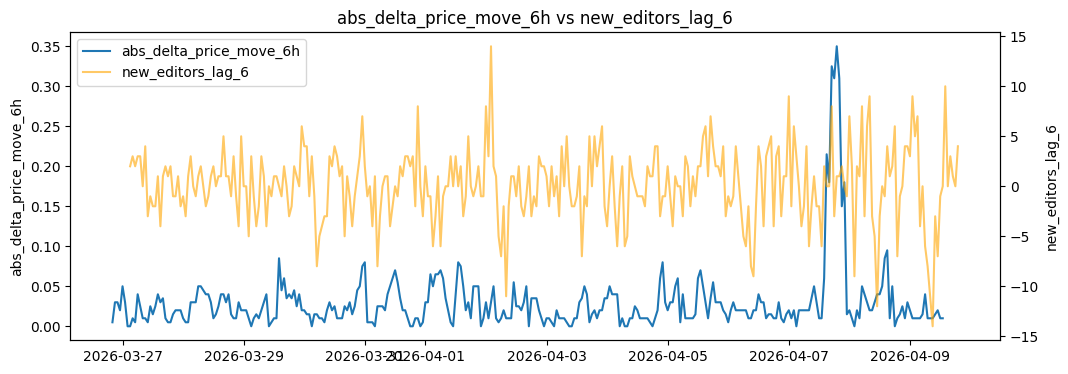

In [29]:
import matplotlib.pyplot as plt

def plot_rolling_delta(col1: str, col2: str):
    fig, ax1 = plt.subplots(figsize=(12,4))
    ax1.plot(df.index, df[col1], label=col1)
    ax1.set_ylabel(col1)

    ax2 = ax1.twinx()
    ax2.plot(df.index, df[col2], color="orange", alpha=0.6, label=col2)
    ax2.set_ylabel(col2)

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.title(f"{col1} vs {col2}")
    plt.show()


plot_rolling_delta("abs_delta_price_move_6h", "new_editors_lag_6")

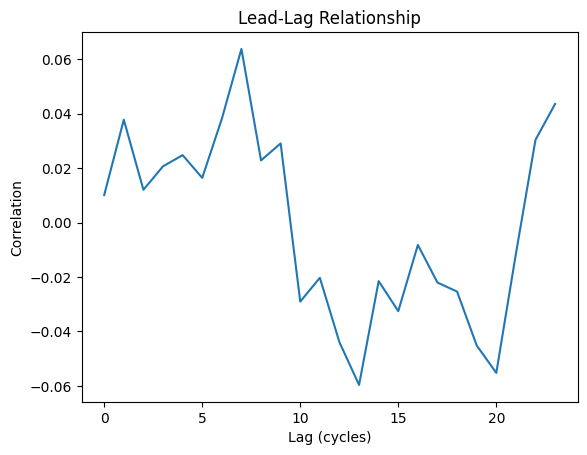

In [30]:
corrs = []
df["target"] = (df["price"].shift(-6) - df["price"]).abs()
for lag in range(0, 24):
    shifted = df["new_editors_3h"].shift(lag)
    corr = shifted.corr(df["target"])
    corrs.append(corr)

import matplotlib.pyplot as plt

plt.plot(range(24), corrs)
plt.xlabel("Lag (cycles)")
plt.ylabel("Correlation")
plt.title("Lead-Lag Relationship")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

# target
selected_features = (
   [f"edits_lag_{i}" for i in range(1, 12)] + 
   [f"new_editors_lag_{i}" for i in range(1, 12)] +
   [f"unique_editors_lag_{i}" for i in range(1, 12)] +
   [f"avg_comments_lag_{i}" for i in range(1, 12)] + 
   [f"new_editors_lag_{i}" for i in range(1, 12)]
   )
# build clean modeling frame
model_df = pd.concat([df[selected_features], df["target"]], axis=1).dropna()

X_clean = model_df[selected_features]
y_clean = model_df["target"]

# split AFTER dropna
split = int(len(model_df) * 0.7)

X_train = X_clean.iloc[:split]
X_test  = X_clean.iloc[split:]
y_train = y_clean.iloc[:split]
y_test  = y_clean.iloc[split:]

# scale using train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# fit
model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

# predict
y_pred = model.predict(X_test_scaled)

print("train len:", len(X_train), "test len:", len(X_test))
print("R²:", r2_score(y_test, y_pred))
print("Corr:", np.corrcoef(y_test, y_pred)[0,1])

# After training, select top 10 most correlated features
correlations = {
    feature: abs(X_train[feature].corr(y_train))
    for feature in selected_features
}
top_features = sorted(correlations, key=correlations.get, reverse=True)[:5]
print("Top 5 correlated features:", top_features)

# Retrain with top 10 features
X_clean_top = model_df[top_features]
X_train_top = X_clean_top.iloc[:split]
X_test_top = X_clean_top.iloc[split:]

scaler_top = StandardScaler()
X_train_scaled_top = scaler_top.fit_transform(X_train_top)
X_test_scaled_top = scaler_top.transform(X_test_top)

model_top = Ridge(alpha=1.0)
model_top.fit(X_train_scaled_top, y_train)

y_pred_top = model_top.predict(X_test_scaled_top)

print("Retrained with top 5 features:")
print("R²:", r2_score(y_test, y_pred_top))
print("Corr:", np.corrcoef(y_test, y_pred_top)[0,1])

train len: 222 test len: 96
R²: -0.04540503563164133
Corr: 0.11283655978205463
Top 5 correlated features: ['unique_editors_lag_6', 'edits_lag_6', 'unique_editors_lag_5', 'edits_lag_5', 'edits_lag_3']
Retrained with top 5 features:
R²: -0.04765754932865218
Corr: 0.13564411350100125
